### **Step-1: Business Problem Understanding**

### 
identify relationship b/w total advertising spend and sales?

our next ad campaign will have a total spend of $20,0000,how many units do we expect to sell as a result of this?
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(r'C:\Users\nagasri15\Downloads\Advertising.csv')
df

,TV,radio,newspaper,sales
0,230100,37800,69200,22100
1,44500,39300,45100,10400
2,17200,45900,69300,9300
3,151500,41300,58500,18500
4,180800,10800,58400,12900
...,...,...,...,...
195,38200,3700,13800,7600
196,94200,4900,8100,9700
197,177000,9300,6400,12800
198,283600,42000,66200,25500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   TV         200 non-null    int64
 1   radio      200 non-null    int64
 2   newspaper  200 non-null    int64
 3   sales      200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [5]:
df.size

800

In [7]:
df.shape

(200, 4)

In [9]:
df.ndim

2

### **Step-2**

In [10]:
df['total_spend']=df['TV']+df['radio']+df['newspaper']
df.head()

,TV,radio,newspaper,sales,total_spend
0,230100,37800,69200,22100,337100
1,44500,39300,45100,10400,128900
2,17200,45900,69300,9300,132400
3,151500,41300,58500,18500,251300
4,180800,10800,58400,12900,250000


In [11]:
df

,TV,radio,newspaper,sales,total_spend
0,230100,37800,69200,22100,337100
1,44500,39300,45100,10400,128900
2,17200,45900,69300,9300,132400
3,151500,41300,58500,18500,251300
4,180800,10800,58400,12900,250000
...,...,...,...,...,...
195,38200,3700,13800,7600,55700
196,94200,4900,8100,9700,107200
197,177000,9300,6400,12800,192700
198,283600,42000,66200,25500,391800


In [12]:
df.drop(columns=['TV','radio','newspaper'],inplace=True)
df.head()

,sales,total_spend
0,22100,337100
1,10400,128900
2,9300,132400
3,18500,251300
4,12900,250000


In [13]:
df.describe()

,sales,total_spend
count,200.000000,200.000000
mean,14022.500000,200860.500000
std,5217.456566,92985.180587
min,1600.000000,11700.000000
25%,10375.000000,123550.000000
50%,12900.000000,207350.000000
75%,17400.000000,281125.000000
max,27000.000000,433600.000000


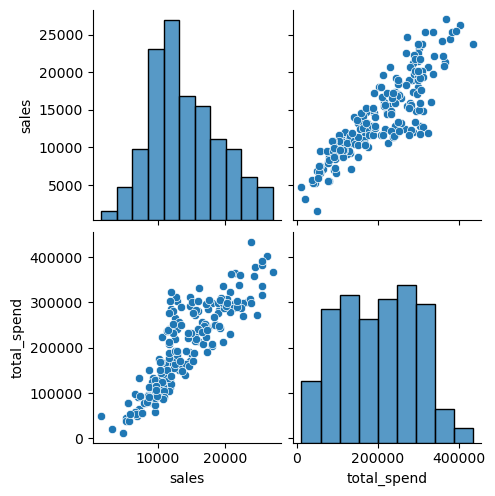

In [14]:
sns.pairplot(df)
plt.show()

In [15]:
df.corr()

,sales,total_spend
sales,1.000000,0.867712
total_spend,0.867712,1.000000


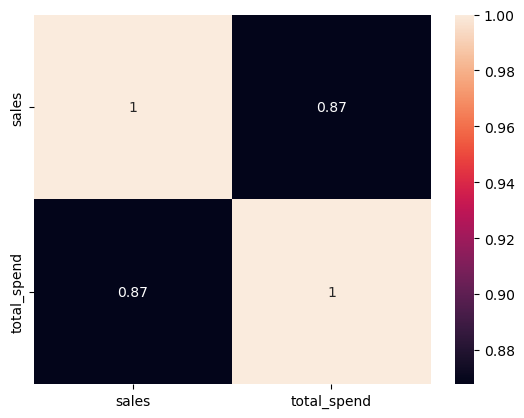

In [16]:
sns.heatmap(df.corr(), annot=True)
plt.show()

### **Data Cleaning**

In [17]:
df.isnull().sum()

sales          0
total_spend    0
dtype: int64

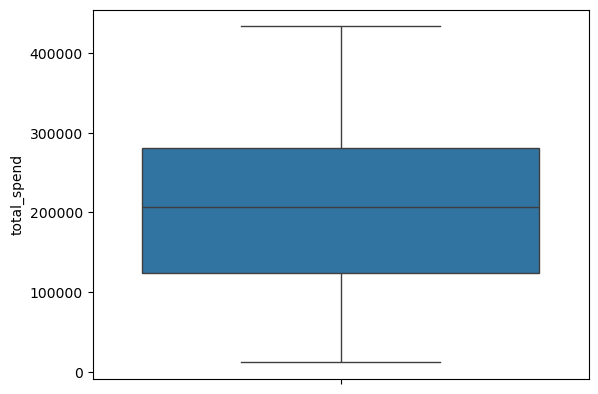

In [18]:
sns.boxplot(df["total_spend"])
plt.show()

### **Data Wrangling**

In [19]:
x=df.drop(columns='sales')
y=df['sales']

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=45)

In [21]:
x_train.shape

(140, 1)

In [22]:
y_train.shape

(140,)

### **Step-4: Modeling**

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model=LinearRegression()

In [26]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
model.intercept_

np.float64(4231.537484184351)

In [28]:
model.coef_

array([0.04821235])

### **Predictions**

In [29]:
train_predictions=model.predict(x_train)

In [30]:
test_predictions=model.predict(x_test)

### **Step-5:Evaluation**

In [31]:
from sklearn.metrics import mean_absolute_error
print('MAE for test data:',mean_absolute_error(y_test,test_predictions))
print('MAE for train data:',mean_absolute_error(y_train,train_predictions))

MAE for test data: 1974.7761234615746
MAE for train data: 1954.164626919143


In [32]:
from sklearn.metrics import mean_squared_error
print('MSE for test data:',mean_squared_error(y_test,test_predictions))
print('MSE for train data:',mean_squared_error(y_train,train_predictions))

MSE for test data: 6380718.337129465
MSE for train data: 6844857.429081763


In [33]:
print("RMSE for test data: ",np.sqrt(mean_squared_error(y_test,test_predictions)))
print("RMSE for train data: ",np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data:  2526.0083802571726
RMSE for train data:  2616.2678435285948


In [34]:
from sklearn.metrics import r2_score
print("R2 for test data: ",r2_score(y_test,test_predictions))
print("R2 for train data: ",r2_score(y_train,train_predictions))

R2 for test data:  0.7384175747285473
R2 for train data:  0.753094788881539


In [35]:
model.score(x_test,y_test)

0.7384175747285473

In [36]:
model.score(x_train,y_train)

0.753094788881539

### **Checklist**

For any Supervised Machine Learning Algorithm (Other than Linear Regression):

Check whether model has overfitting or underfitting problem

Is Test Accuracy ≈ Cross validation Score

Check model meets the business problem requirements

Finally, save the model and share to the deployment team

For Linear Regression, in addition we have to

In [37]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=5)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

[0.74964192 0.79455226 0.76417134 0.74872042 0.65980565]
Cross Validation Score: 0.7433783178555419


In [38]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,x,y,cv=6)
print(scores)
cv_score=scores.mean()
print('Cross Validation Score:',cv_score)

[0.78183993 0.71787347 0.78350538 0.76563644 0.6841     0.72458008]
Cross Validation Score: 0.7429225500042018


### **Check for assumptions**
### **1.Linearity of error**

In [39]:
test_res=y_test-test_predictions

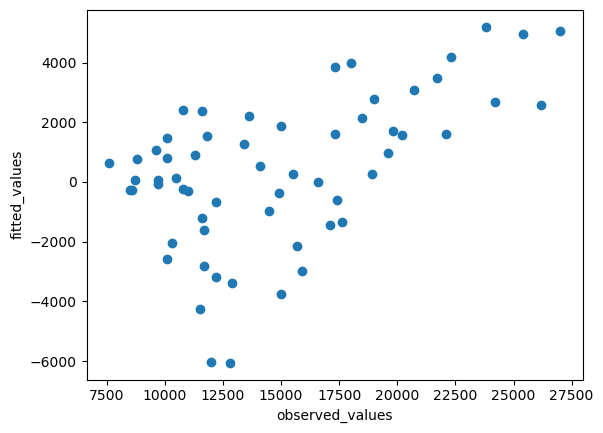

In [40]:
plt.scatter(y_test,test_res)
plt.xlabel('observed_values')
plt.ylabel('fitted_values')
plt.show()

### **2.Normality of Errors**

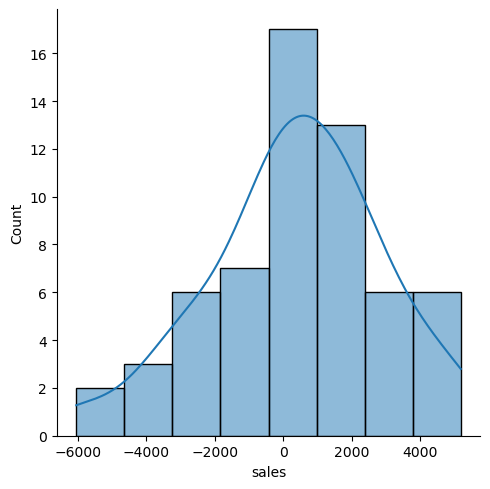

In [41]:
sns.displot(test_res,kde=True)
plt.show()

### **3.Equal Variance of Errors(Homoscadescity)**

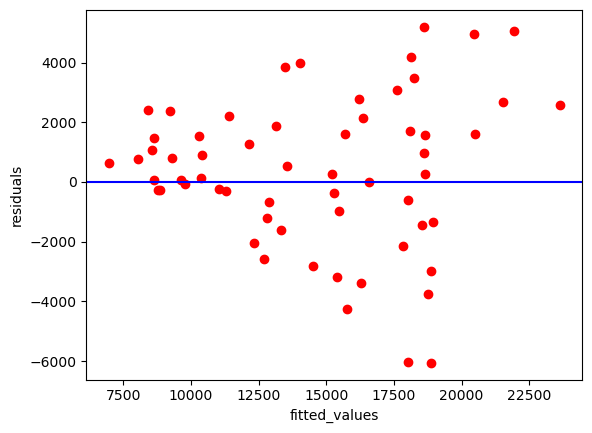

In [42]:
plt.scatter(test_predictions,test_res,c='r')
plt.axhline(y=0,color='blue')
plt.xlabel('fitted_values')
plt.ylabel('residuals')
plt.show()

In [43]:
import statsmodels.formula.api as smf
model2=smf.ols('y~x',data=df).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     603.4
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           5.06e-62
Time:                        10:34:37   Log-Likelihood:                -1855.4
No. Observations:                 200   AIC:                             3715.
Df Residuals:                     198   BIC:                             3721.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4243.0282    438.525      9.676      0.000    3378.249    5107.807
x              0.0487      0.002     24.564      0.000       0.045       0.053
==============================================================================
Omnibus:                        6.851   Durbin-Watson:                   1.967
Prob(Omnibus):                  0.033   Jarque-Bera (JB):                6.692
Skew:                          -0.373   Prob(JB):                       0.0352
Kurtosis:                       3.495   Cond. No.                     5.28e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.28e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### **Step-6:Final Inferences**

In [44]:
model.predict([[321400]])

C:\Users\nagasri15\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([19726.98552637])

In [45]:
from joblib import dump

In [46]:
dump(model,'sales_model.joblib')

['sales_model.joblib']

### **Load a Model**

In [47]:
from joblib import load

In [48]:
loaded_model=load('sales_model.joblib')

In [49]:
loaded_model.predict([[200000]])

C:\Users\nagasri15\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13874.0067077])